In [2]:
import yaml
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np
import itertools


In [68]:
def plot_curves(x_col, y_col, group_columns=None, filters=None,
                x_label="", y_label="", title="", df_source=None):
    """
    Generic function to plot multiple curves on the same graph.

    Parameters:
    - x_col (str): Column name for X-axis (required)
    - y_col (str): Column name for Y-axis (required)
    - group_columns (list, optional): Columns used to create separate curves
    - filters (dict, optional): Filter data by column values (ex: {"topology": "TORUS"})
    - x_label (str): Label for X-axis
    - y_label (str): Label for Y-axis
    - title (str): Plot title
    - df_source (DataFrame): DataFrame to use (default: global df)
    """

    if df_source is None:
        df_source = df

    # Apply filters if provided
    if filters is not None:
        for col, val in filters.items():
            df_source = df_source[df_source[col] == val]

    # Default labels
    if not x_label:
        x_label = x_col.replace('_', ' ').title()

    if not y_label:
        y_label = y_col.replace('_', ' ').title()

    if not title:
        title = f"{y_col.replace('_',' ')} vs {x_col.replace('_',' ')}"

    plt.figure(figsize=(10, 6))

    # No grouping
    if group_columns is None:
        plt.plot(df_source[x_col], df_source[y_col], marker='o', label='All Data')

    else:
        group_values = [sorted(df_source[col].unique()) for col in group_columns]

        for combo in itertools.product(*group_values):

            filter_condition = pd.Series(True, index=df_source.index)
            label_parts = []

            for col, val in zip(group_columns, combo):
                filter_condition &= (df_source[col] == val)
                label_parts.append(f"{col}={val}")

            subset = df_source[filter_condition]

            if subset.empty:
                continue

            label = ", ".join(label_parts)

            plt.plot(subset[x_col], subset[y_col], marker='o', label=label)

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xscale("log")
    plt.show()

In [47]:
def load_config(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

def save_config(config, path):
    with open(path, 'w') as f:
        yaml.dump(config, f, sort_keys=False)


In [48]:
def update_parameter(config, key_path, value):
    """
    key_path: liste des clés hiérarchiques
    Exemple:
        ["packet_injection_rate"]
        ["Hubs", "0", "attached_nodes"]
    """
    ref = config
    for key in key_path[:-1]:
        if key.isdigit():
            key = int(key)
        ref = ref[key]
    
    last_key = key_path[-1]
    if last_key.isdigit():
        last_key = int(last_key)

    ref[last_key] = value


In [49]:
# new helper for parameter parsing

def parse_param(spec):
    """Convert a parameter specification into a mapping of key paths to value lists.

    * If ``spec`` is a string, it's treated as a path to a YAML file that
      contains a dict of parameter names to lists of possible values.
    * If ``spec`` is already a dict, it can be used directly.  Parameter keys
      are written with dots to separate levels (e.g. ``"packet_injection_rate"``
      or ``"Hubs.0.attached_nodes"``).

    Returns a dict where each key is a tuple of path components and the value
    is the corresponding list of values.
    """
    if isinstance(spec, str):
        with open(spec) as f:
            params = yaml.safe_load(f)
    else:
        params = spec

    parsed = {}
    for key, values in params.items():
        # support comma-separated value strings
        if isinstance(values, str):
            values = [v.strip() for v in values.split(',')]
        path = tuple(key.split('.'))
        parsed[path] = values
    return parsed


In [50]:
# Utility: build a 2x2 mesh block Hub description for an entire mesh

def Mesh_block_2x2(mesh_dim_x, mesh_dim_y, to_tile_buffer_size=4, from_tile_buffer_size=4,
                   rx_buffer_size=4, tx_buffer_size=4, rx_channels=None, tx_channels=None):
    """Return a hubs dictionary suitable for merging into the YAML config.

    This function implements a parity-based hub assignment where each PE is attached
    to a hub based on its coordinate parity: hub_id = (x % 2) + 2 * (y % 2).
    This creates exactly 4 hubs regardless of mesh size, with even/odd partition across both dimensions:
    - Hub 0: nodes with x%2==0 and y%2==0 (top-left partition)
    - Hub 1: nodes with x%2==1 and y%2==0 (top-right partition)
    - Hub 2: nodes with x%2==0 and y%2==1 (bottom-left partition)
    - Hub 3: nodes with x%2==1 and y%2==1 (bottom-right partition)

    All hubs are interconnected via wireless channels, creating a hub mesh overlay.

    Tis function *does not* wrap the result in an outer ``{'Hubs': ...}`` key;
    callers should insert it under the ``Hubs`` field themselves.
    This prevents duplicate ``Hubs:`` entries when ``update_parameter`` replaces the top-level key.

    Parameters
    - mesh_dim_x, mesh_dim_y: overall mesh size (must be multiples of 2)
    - to_tile_buffer_size, from_tile_buffer_size, rx_buffer_size, tx_buffer_size: buffer configurations
    - rx_channels, tx_channels: wireless channel lists (default=[0])

    Returns a dict of hubs (not wrapped) suitable for ``config['Hubs']``.
    """
    if mesh_dim_x % 2 != 0 or mesh_dim_y % 2 != 0:
        raise ValueError("mesh_dim_x and mesh_dim_y must be multiples of 2")

    if rx_channels is None:
        rx_channels = [0]
    if tx_channels is None:
        tx_channels = [0]

    defaults = {
        "rx_radio_channels": rx_channels,
        "tx_radio_channels": tx_channels,
        "attached_nodes": [],
        "to_tile_buffer_size": to_tile_buffer_size,
        "from_tile_buffer_size": from_tile_buffer_size,
        "rx_buffer_size": rx_buffer_size,
        "tx_buffer_size": tx_buffer_size,
    }

    # Partition PEs into 4 hubs based on coordinate parity
    hubs_dict = {0: [], 1: [], 2: [], 3: []}

    for y in range(mesh_dim_y):
        for x in range(mesh_dim_x):
            node_id = y * mesh_dim_x + x
            # Assign hub based on parity: (x % 2) + 2 * (y % 2)
            hub_id = (x % 2) + 2 * (y % 2)
            hubs_dict[hub_id].append(node_id)

    # Build final hubs dict with defaults and attached nodes
    hubs = {"defaults": defaults}
    for hub_id in range(4):
        hubs[hub_id] = {"attached_nodes": hubs_dict[hub_id]}

    return hubs

In [51]:
def generate_hubs(mesh_dim_x, mesh_dim_y,
                  block_dim_x=2, block_dim_y=2,
                  to_tile_buffer_size=1024,
                  from_tile_buffer_size=1024,
                  rx_buffer_size=1024,
                  tx_buffer_size=1024,
                  rx_channels=None,
                  tx_channels=None):

    if mesh_dim_x % block_dim_x != 0 or mesh_dim_y % block_dim_y != 0:
        raise ValueError("Mesh dimensions must be divisible by block dimensions")

    if rx_channels is None:
        rx_channels = list(range((mesh_dim_x // block_dim_x) * (mesh_dim_y // block_dim_y)))
    if tx_channels is None:
        tx_channels = list(range((mesh_dim_x // block_dim_x) * (mesh_dim_y // block_dim_y)))

    hubs = {}

    hub_id = 0

    for by in range(0, mesh_dim_y, block_dim_y):
        for bx in range(0, mesh_dim_x, block_dim_x):

            attached_nodes = []

            for dy in range(block_dim_y):
                for dx in range(block_dim_x):
                    x = bx + dx
                    y = by + dy
                    node_id = y * mesh_dim_x + x
                    attached_nodes.append(node_id)

            hubs[hub_id] = {
                "attached_nodes": attached_nodes,
                "rx_radio_channels": rx_channels,
                "tx_radio_channels": tx_channels,
                "to_tile_buffer_size": to_tile_buffer_size,
                "from_tile_buffer_size": from_tile_buffer_size,
                "rx_buffer_size": rx_buffer_size,
                "tx_buffer_size": tx_buffer_size,
            }

            hub_id += 1

    return hubs

In [52]:
def generate_hub_ring(mesh_dim_x, mesh_dim_y,
                      to_tile_buffer_size=4,
                      from_tile_buffer_size=4,
                      rx_buffer_size=4,
                      tx_buffer_size=4):

    if mesh_dim_x != mesh_dim_y:
        raise ValueError("Mesh must be square (XxX)")

    N = mesh_dim_x
    total_nodes = N * N

    hubs = {}

    # coordonnées -> id
    def node_id(x, y):
        return y * N + x

    visited = set()
    rings = []

    layer = 0

    while layer < (N + 1) // 2:

        ring = []

        # top
        for x in range(layer, N-layer):
            ring.append(node_id(x, layer))

        # right
        for y in range(layer+1, N-layer):
            ring.append(node_id(N-layer-1, y))

        # bottom
        if N-layer-1 != layer:
            for x in range(N-layer-2, layer-1, -1):
                ring.append(node_id(x, N-layer-1))

        # left
        if N-layer-1 != layer:
            for y in range(N-layer-2, layer, -1):
                ring.append(node_id(layer, y))

        rings.append(ring)
        layer += 1

    hub_id = 0

    for ring in rings:

        ring_size = len(ring)

        for i, node in enumerate(ring):

            prev_hub = ring[(i-1) % ring_size]
            next_hub = ring[(i+1) % ring_size]

            hubs[hub_id] = {
                "attached_nodes": [node],
                "rx_radio_channels": [prev_hub, next_hub],
                "tx_radio_channels": [prev_hub, next_hub],
                "to_tile_buffer_size": to_tile_buffer_size,
                "from_tile_buffer_size": from_tile_buffer_size,
                "rx_buffer_size": rx_buffer_size,
                "tx_buffer_size": tx_buffer_size,
            }

            hub_id += 1

    return hubs

In [54]:
def run_simulation(noxim_exec, config_path, power_path, output_file):
    # ensure SystemC library is locatable
    env = os.environ.copy()
    env["LD_LIBRARY_PATH"] = "/home/maximilien/systemc-2.3.3/build/src/.libs"

    cmd = [
        noxim_exec,
        "-power", power_path,
        "-config", config_path,
        "-seed", "42"  # fixed seed for reproducibility
    ]

    with open(output_file, "w") as f:
        subprocess.run(cmd, stdout=f, stderr=subprocess.STDOUT, env=env)


In [55]:
def parse_noxim_output(output_file):
    metrics = {}

    patterns = {
        "total_received_packets": r"Total received packets:\s+(\d+)",
        "total_received_flits": r"Total received flits:\s+(\d+)",
        "received_ideal_ratio": r"Received/Ideal flits Ratio:\s+([\d\.eE+-]+)",
        "average_wireless_utilization": r"Average wireless utilization:\s+([\d\.eE+-]+)",
        "global_average_delay_cycles": r"Global average delay \(cycles\):\s+([\d\.eE+-]+)",
        "max_delay_cycles": r"Max delay \(cycles\):\s+([\d\.eE+-]+)",
        "network_throughput_flits_cycle": r"Network throughput \(flits/cycle\):\s+([\d\.eE+-]+)",
        "average_ip_throughput": r"Average IP throughput \(flits/cycle/IP\):\s+([\d\.eE+-]+)",
        "average_active_ip_throughput": r"Average active IP throughput \(flits/cycle/active IP\):\s+([\d\.eE+-]+)",
        "total_energy_J": r"Total energy \(J\):\s+([\d\.eE+-]+)",
        "dynamic_energy_J": r"Dynamic energy \(J\):\s+([\d\.eE+-]+)",
        "static_energy_J": r"Static energy \(J\):\s+([\d\.eE+-]+)"
    }

    with open(output_file, "r") as f:
        content = f.read()

        for key, pattern in patterns.items():
            match = re.search(pattern, content)
            if match:
                value = match.group(1)
                try:
                    metrics[key] = float(value)
                except:
                    metrics[key] = value

    return metrics


In [56]:
# helper that runs a full sweep over parsed parameters

def run_sweep(param_dict, noxim_exec, base_config, power_file,
              temp_config="config_temp.yaml", output_file="output.txt"):
    """
    Execute Noxim simulations for each combination of parameters.

    * ``param_dict`` is the output of :func:`parse_param` (mapping tuple paths
      to lists of values).
    * ``nozim_exec`` and the file paths are the same used by
      :func:`run_simulation`.

    Returns a list of metric dictionaries, each extended with the parameter
    values used for that run (keys are dot‑joined paths).
    """

    results = []
    keys = list(param_dict.keys())
    value_lists = [param_dict[k] for k in keys]

    for combo in itertools.product(*value_lists):
        config = load_config(base_config)
        for k, val in zip(keys, combo):
            update_parameter(config, list(k), val)
        save_config(config, temp_config)

        run_simulation(noxim_exec, temp_config, power_file, output_file)
        metrics = parse_noxim_output(output_file)
        for k, val in zip(keys, combo):
            metrics[".".join(k)] = val
        results.append(metrics)

    return results


In [112]:
# main execution
noxim_exec = "./noxim" 
power_file = "power.yaml"
base_config = "../config_examples/Mesh_hybride.yaml"

''' Simulation parameters '''
injection_rates = np.logspace(np.log10(0.01), np.log10(0.3), num=10, base=10)  # from 0.01 to 0.5 in 5 steps
injection_rates = injection_rates.tolist()
#injection_rates = [0.01]

''' Topologie parameters '''
topology = ["MESH", "TORUS"]
mesh_dim_y = 16
mesh_dim_x = 16
#buffer_depths = [4, 32]
buffer_depths = [32]
flit_size = [16]
#routing_algorithm = ["DELTA", "WEST_FIRST", "NORTH_LAST", "NEGATIVE_FIRST", "ODD_EVEN", "DYAD", "HUB_FIRST"]
routing_algorithm = ["XY_TORUS"]
selection_strategy = ["RANDOM"]

''' Hub Parameters '''
use_winoc = [True]
to_tile_buffer_size = 1024
from_tile_buffer_size = 1024
rx_buffer_size = 1024
tx_buffer_size = 1024
#hubs = [generate_hubs(mesh_dim_x=mesh_dim_x, mesh_dim_y=mesh_dim_y, block_dim_x=4, block_dim_y=4,
#                     to_tile_buffer_size=to_tile_buffer_size, from_tile_buffer_size=from_tile_buffer_size,
#                     rx_buffer_size=rx_buffer_size, tx_buffer_size=tx_buffer_size),
#        generate_hubs(mesh_dim_x=mesh_dim_x, mesh_dim_y=mesh_dim_y, block_dim_x=2, block_dim_y=2,
#                     to_tile_buffer_size=to_tile_buffer_size, from_tile_buffer_size=from_tile_buffer_size,
#                     rx_buffer_size=rx_buffer_size, tx_buffer_size=tx_buffer_size),]
hubs = [generate_hubs(mesh_dim_x=mesh_dim_x, mesh_dim_y=mesh_dim_y, block_dim_x=2, block_dim_y=2,
                     to_tile_buffer_size=to_tile_buffer_size, from_tile_buffer_size=from_tile_buffer_size,
                     rx_buffer_size=rx_buffer_size, tx_buffer_size=tx_buffer_size),
        generate_hubs(mesh_dim_x=mesh_dim_x, mesh_dim_y=mesh_dim_y, block_dim_x=4, block_dim_y=4,
                     to_tile_buffer_size=to_tile_buffer_size, from_tile_buffer_size=from_tile_buffer_size,
                     rx_buffer_size=rx_buffer_size, tx_buffer_size=tx_buffer_size)]

''' Trace Parameters '''
trace_mode = [False]
trace_filename = ["trace"]  # base name for trace files (without extension)

param = parse_param({
    "packet_injection_rate": injection_rates,
    "topology": topology,
    "mesh_dim_x": [mesh_dim_x],
    "mesh_dim_y": [mesh_dim_y],
    "buffer_depth": buffer_depths,
    "flit_size": flit_size,
    "routing_algorithm": routing_algorithm,
    "selection_strategy": selection_strategy,
    "use_winoc": use_winoc,
    "trace_mode": trace_mode,
    "trace_filename": trace_filename,
    "Hubs": hubs
})
#print(param)

# run the sweep and collect results
results = run_sweep(param, noxim_exec, base_config, power_file,
                    temp_config="config_temp.yaml", output_file="output.txt")

# convert results to DataFrame for analysis
df = pd.DataFrame(results)

#df

#  Global Average Delay vs Injection Rate

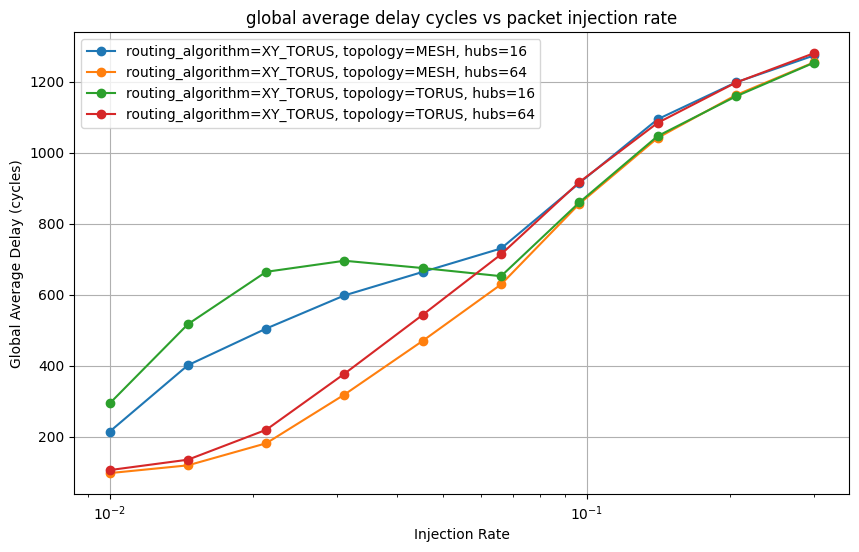

In [113]:
df["hubs"] = df["Hubs"].apply(lambda h: f"{len(h)}")
plot_curves("packet_injection_rate", "global_average_delay_cycles",
            group_columns=["routing_algorithm", "topology", "hubs"],
            #filters={"topology": "TORUS"},
            filters={"routing_algorithm": "XY_TORUS"},
            x_label="Injection Rate",
            y_label="Global Average Delay (cycles)")

# Throughput vs Injection Rate

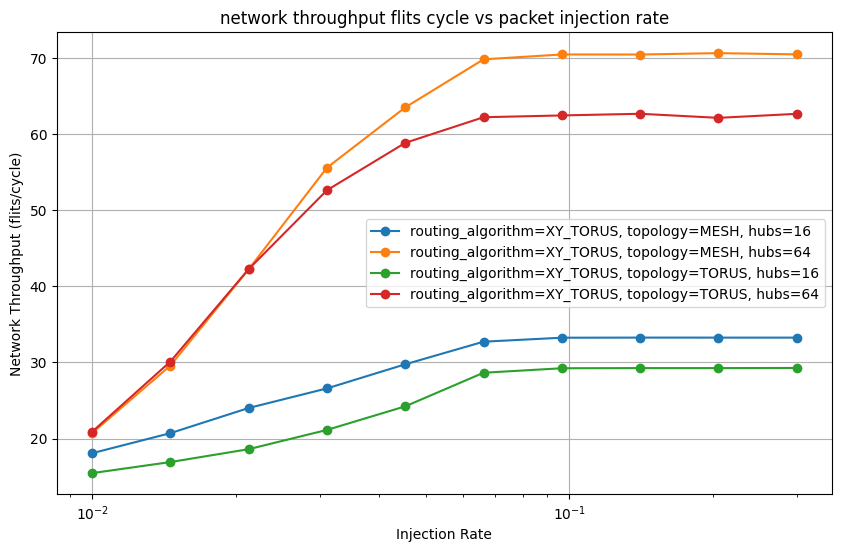

In [114]:
plot_curves("packet_injection_rate", "network_throughput_flits_cycle",
            group_columns=["routing_algorithm", "topology", "hubs"],
            #filters={"topology": "TORUS"},# "hubs": "64"},
            x_label="Injection Rate",
            y_label="Network Throughput (flits/cycle)")

#  max_delay_cycles vs Injection Rate

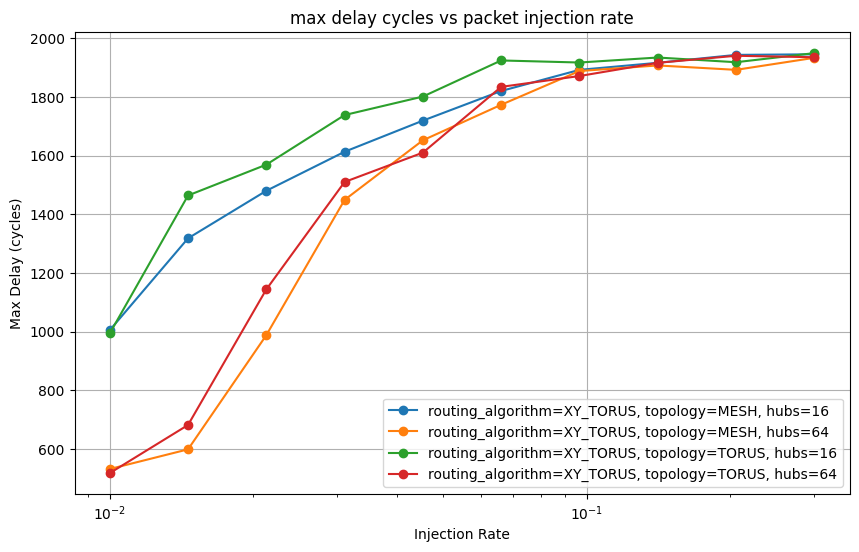

In [115]:
plot_curves("packet_injection_rate", "max_delay_cycles",
            group_columns=["routing_algorithm", "topology", "hubs"],
            #filters={"topology": "TORUS"},
            x_label="Injection Rate",
            y_label="Max Delay (cycles)")

# total_received_packets vs Injection rate

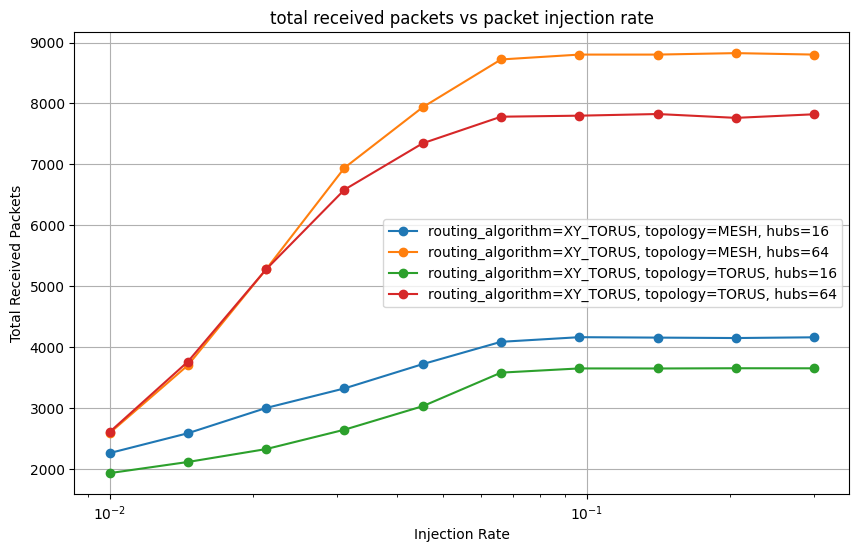

In [116]:
plot_curves("packet_injection_rate", "total_received_packets",
            group_columns=["routing_algorithm", "topology", "hubs"],
            x_label="Injection Rate",
            y_label="Total Received Packets")

# Energy vs Injection Rate

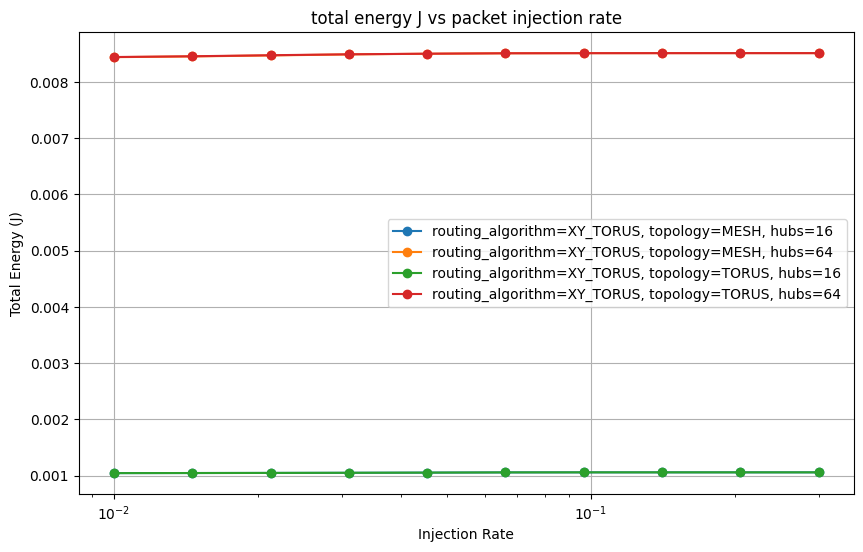

In [117]:
plot_curves("packet_injection_rate", "total_energy_J",
            group_columns=["routing_algorithm", "topology", "hubs"],
            x_label="Injection Rate",
            y_label="Total Energy (J)")

# dynamic_energy_J vs Injection Rate

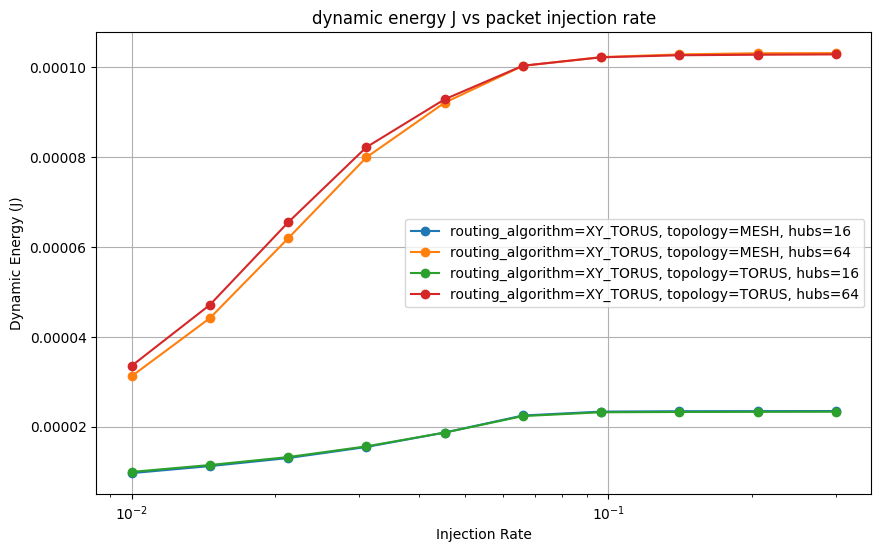

In [118]:
plot_curves("packet_injection_rate", "dynamic_energy_J",
            group_columns=["routing_algorithm", "topology", "hubs"],
            x_label="Injection Rate",
            y_label="Dynamic Energy (J)")

# static_energy_J vs Injection Rate

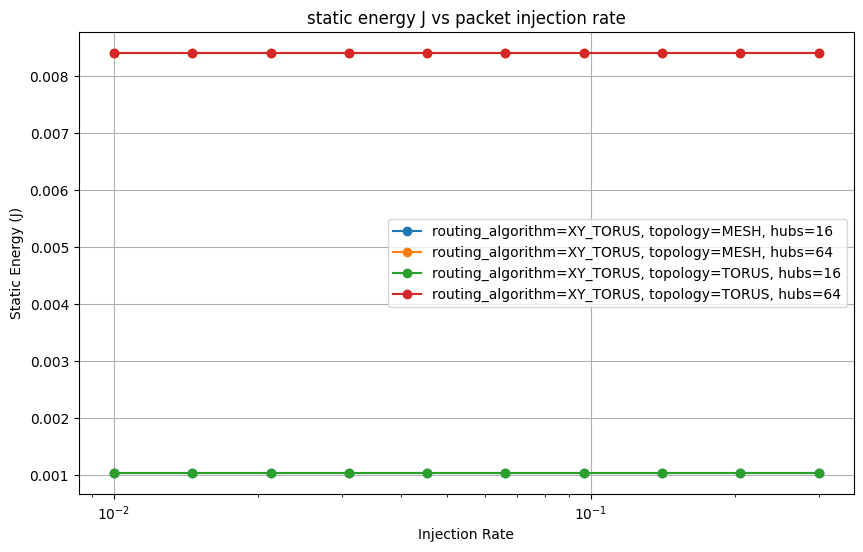

In [119]:
plot_curves("packet_injection_rate", "static_energy_J",
            group_columns=["routing_algorithm", "topology", "hubs"],
            x_label="Injection Rate",
            y_label="Static Energy (J)")